**Project Title:** House Price Prediction: A Regression Pipeline

**Group Information:** Hamidul Islam [23-50447-1], Niladri Roy Nion [23-51202-1], T.A Nahian [23-51257-1]



**DW-1: Problem Formulation**

***Objective:*** Predict the continuous price of a house based on its physical and locational features.  
***Success Criteria:*** A useful result will perform better than a mean-prediction baseline, evaluated using MAE, RMSE, and $R^2$.  

**DW-2: Data Provenance**

***Source:*** Housing Prices Dataset (Kaggle).

***Privacy/Ethics:*** This is public, anonymized real estate data; no personal identifiers are exposed.

**DW-3: Data audit**

In [14]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Load the dataset
df_raw = pd.read_csv('/content/Housing.csv')
df = df_raw.copy()

print("--- DW-3: Data Audit ---")
# Check types, ranges, duplicates, missing values, and outliers
print("\n1. Data Info & Missing Values:")
display(df.info())

print(f"\n2. Duplicates found: {df.duplicated().sum()}")

print("\n3. Summary Statistics:")
display(df.describe(include='all'))

--- DW-3: Data Audit ---

1. Data Info & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              545 non-null    int64  
 2   bedrooms          543 non-null    float64
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          545 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  544 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 55.5+ KB


None


2. Duplicates found: 0

3. Summary Statistics:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,543.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,544
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,226
mean,4.766729e+06,5150.541284,2.965009,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.739421,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


**DW-4: Exploratory analysis**

--- DW-4: Exploratory Analysis ---


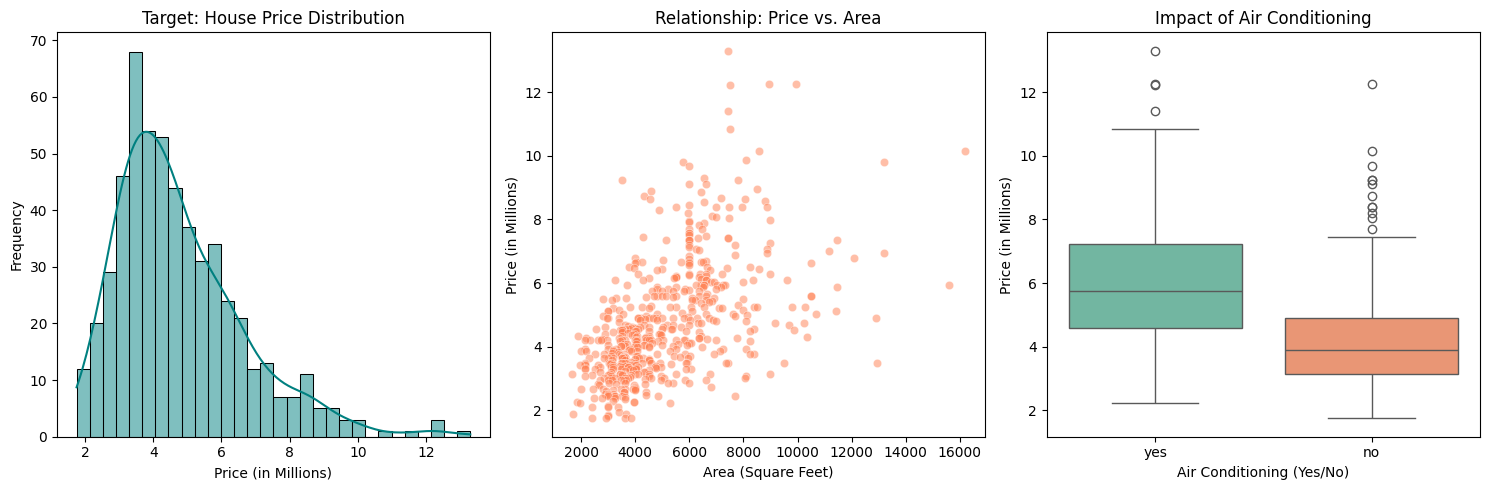

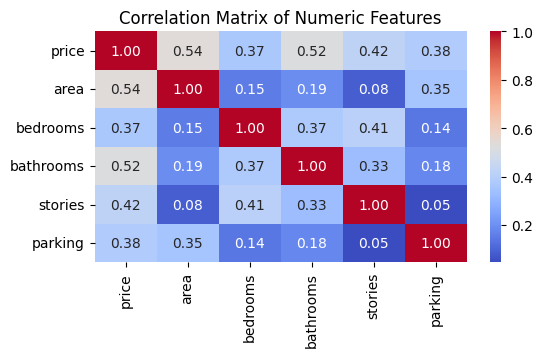

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- DW-4: Exploratory Analysis ---")

# Figure 1: Distributions and Relationships
plt.figure(figsize=(15, 5))

# Plot A: Target Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['price'] / 1000000, bins=30, kde=True, color='teal')
plt.title('Target: House Price Distribution')
plt.xlabel('Price (in Millions)')
plt.ylabel('Frequency')

# Plot B: Numeric Relationship
plt.subplot(1, 3, 2)
sns.scatterplot(x=df['area'], y=df['price'] / 1000000, alpha=0.5, color='coral')
plt.title('Relationship: Price vs. Area')
plt.xlabel('Area (Square Feet)')
plt.ylabel('Price (in Millions)')

# Plot C: Categorical Relationship (Boxplot)
plt.subplot(1, 3, 3)
sns.boxplot(x=df['airconditioning'], y=df['price'] / 1000000, hue=df['airconditioning'], palette='Set2', legend=False)
plt.title('Impact of Air Conditioning')
plt.xlabel('Air Conditioning (Yes/No)')
plt.ylabel('Price (in Millions)')

plt.tight_layout()
plt.show()

# Figure 2: Correlation Heatmap for Numeric Features
plt.figure(figsize=(6, 3))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

**DW-5: Split design**

In [16]:
from sklearn.model_selection import train_test_split

# Define inputs (X) and target (y)
X = df.drop(columns=['price'])
y = df['price']

# Create train/test splits BEFORE learning preprocessing choices to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"DW-5: Training data shape: {X_train.shape}")
print(f"DW-5: Testing data shape: {X_test.shape}")

DW-5: Training data shape: (436, 12)
DW-5: Testing data shape: (109, 12)


**DW-6: Preprocessing**

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Fit imputation, encoding, and scaling ONLY
numeric_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                        'airconditioning', 'prefarea', 'furnishingstatus']

# Numeric Pipeline: Median imputation -> Standard Scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Mode imputation -> One-Hot Encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

print("DW-6: Leakage-safe preprocessing pipeline defined successfully.")

DW-6: Leakage-safe preprocessing pipeline defined successfully.


**DW-7: Baseline**

In [18]:
from sklearn.dummy import DummyRegressor

# Implement a simple reference result (mean predictor)
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DummyRegressor(strategy='mean'))
])

baseline_model.fit(X_train, y_train)
print("DW-7: Mean-prediction baseline model trained.")

DW-7: Mean-prediction baseline model trained.


**DW-8: Model Development**

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Train candidate models using training data

# 1. Linear Regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)

# 2. Justified Alternative: Random Forest (Captures non-linear relationships)
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_model.fit(X_train, y_train)

print("DW-8: Linear Regression and Random Forest candidate models trained.")

DW-8: Linear Regression and Random Forest candidate models trained.


**DW-9: Final evaluation**

--- DW-9: Final Evaluation & Comparison ---


,Model,MAE,RMSE,R²
0,Baseline (Mean),1748624.607,2268298.228,-0.018
1,Linear Reg.,970043.404,1324506.960,0.653
2,Random Forest,1021151.081,1399758.195,0.612


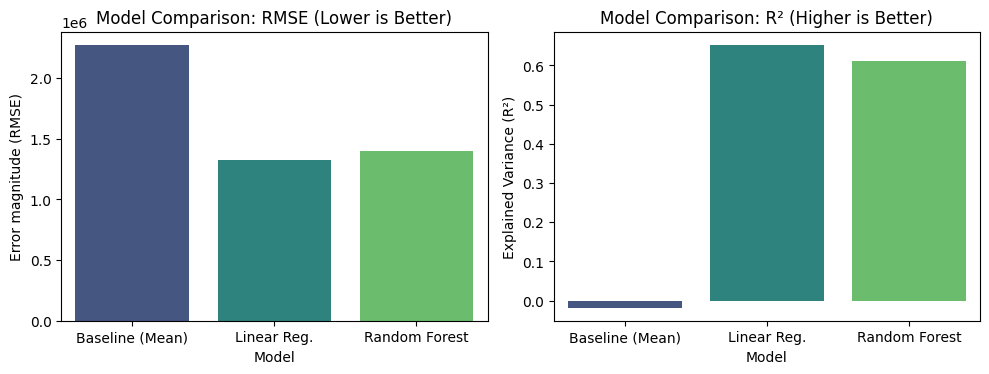

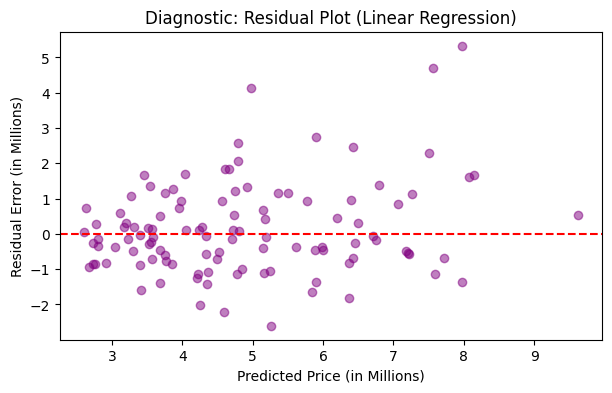

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Evaluate models ONCE on untouched test data
def get_metrics(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2}, preds

print("--- DW-9: Final Evaluation & Comparison ---")

# 1. Collect metrics for all models
metrics_base, preds_base = get_metrics("Baseline (Mean)", baseline_model, X_test, y_test)
metrics_lr, preds_lr = get_metrics("Linear Reg.", lr_model, X_test, y_test)
metrics_rf, preds_rf = get_metrics("Random Forest", rf_model, X_test, y_test)

# 2. Create and display a Comparison Table
results_df = pd.DataFrame([metrics_base, metrics_lr, metrics_rf])
display(results_df.round(3))

# 3. Visual Comparison Chart
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison: RMSE (Lower is Better)')
plt.ylabel('Error magnitude (RMSE)')

plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x='Model', y='R²', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison: R² (Higher is Better)')
plt.ylabel('Explained Variance (R²)')

plt.tight_layout()
plt.show()

# 4. Diagnostic Requirement: Residual Plot for the best model
plt.figure(figsize=(7, 4))
residuals_lr = y_test - preds_lr
plt.scatter(preds_lr / 1000000, residuals_lr / 1000000, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Diagnostic: Residual Plot (Linear Regression)')
plt.xlabel('Predicted Price (in Millions)')
plt.ylabel('Residual Error (in Millions)')
plt.show()



**Visual Proof for Best Performed Model (Linear Regression)**

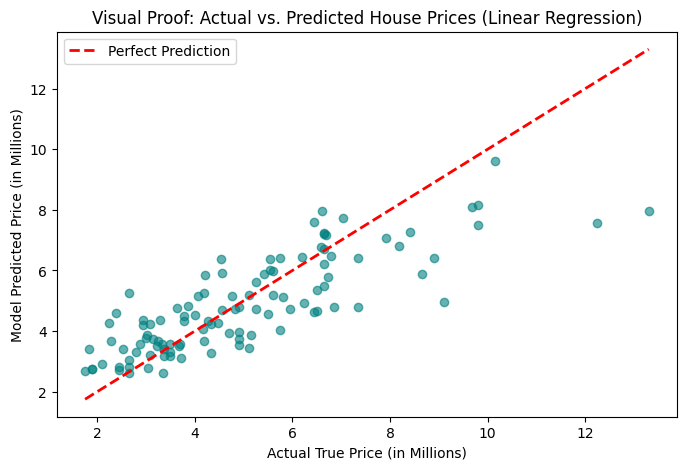

In [38]:
import matplotlib.pyplot as plt

# Create an Actual vs. Predicted plot for Linear Regression
plt.figure(figsize=(8, 5))

# We divide by 1,000,000 for readable axes (Accessibility requirement)
actual_prices = y_test / 1000000
predicted_prices = preds_lr / 1000000

# Plot the scatter of our linear regression predictions
plt.scatter(actual_prices, predicted_prices, alpha=0.6, color='teal')

# Draw a red diagonal line representing "Perfect Predictions"
max_val = max(max(actual_prices), max(predicted_prices))
min_val = min(min(actual_prices), min(predicted_prices))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Visual Proof: Actual vs. Predicted House Prices (Linear Regression)')
plt.xlabel('Actual True Price (in Millions)')
plt.ylabel('Model Predicted Price (in Millions)')
plt.legend()
plt.show()

**DW-10: Interpretation and Limitations**
* **Model Performance & Comparison:** Based on our final evaluation metrics and visual comparison charts, **Linear Regression performed best** among our candidate models, achieving a higher $R^2$ score and lower error magnitudes (RMSE and MAE) than both the baseline and the Random Forest model.
* **Patterns & Errors:** Although Linear Regression proved to be the strongest model, our diagnostic residual plot and actual vs. predicted visualization reveal signs of heteroscedasticity. Specifically, prediction errors fan out and grow larger as house prices increase, indicating that the model struggles to accurately value extreme high-end or luxury homes.
* **Assumptions & Limits:** The model relies on the assumption of linearity between input features (such as area) and house prices. Consequently, it should not be used to predict prices outside its original geographic market or collection time period, as local market shifts and distribution changes will render its predictions unreliable.